In [ ]:
#import all requires libraries

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraries imported successfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#load the student dataset

df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded:{df.shape[0]} students,{df.shape[1]} columns")
print(f"columns:{df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded:30 students,13 columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
#create sqlite3

conn=sqlite3.connect('college.db')
cursor=conn.cursor()

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False

)
cursor.execute("SELECT COUNT(*) FROM students")

count = cursor.fetchone()[0]
#fetchone() retrieves the first result row
print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has {count} rows")

Database 'college.db' created successfully!
Table 'students' has 30 rows


In [ ]:
#inspect the table structure

cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall()
print("Table structure of'students':")
print(f"{'Column Name':<25} {'Data Type':<12}")
print("-" * 38)
for col in columns_info:
  print(f"{col[1]:<25} {col[2]:<12}")

Table structure of'students':
Column Name               Data Type   
--------------------------------------
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


The Standard SQl Query pattern

SELECT  column1,column2  --Which columns to show
FROM  table_name         -- which table to read from
WHERE  condition         --Filter rows(optional)
GROUP BY column          --Group rows(optional)
HAVING  group_condition  --Filter groups
ORDER  BY column DESC    --Sort results
LIMIT 10;                --Max rows to return

In [ ]:
#help function to run SQL queries

def run_query(sql, description=""):
  """
  Runs a SQL query and returns results as a Pandas DataFrames.

  Parameters:
  -----------
  sql         : str - The SQl query to execute
  description : str - A lable to print above the results

  Returns:
  ----------
  Pandas DataFrame containing the query results
  """
  if description:
    print(f"\n{'='*55}")
    print(f" {description}")
    print(f"{'='*55}")

  result = pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

print("Helper function 'run_query' defined successfully!")
print("Usage; run_query(sql_string,description_label)")

Helper function 'run_query' defined successfully!
Usage; run_query(sql_string,description_label)


In [ ]:
query1 = """
  SELECT student_id,name,department,math_score,attendance_percentage
  FROM students
"""
result1 = run_query(query1, "Query 1 : All students and their scores")


 Query 1 : All students and their scores
 student_id           name       department  math_score  attendance_percentage
       1001   Aarav Sharma Computer Science          85                     92
       1002    Priya Patel Computer Science          76                     87
       1003    Rohit Verma      Electronics          65                     78
       1004    Sneha Reddy       Mechanical          70                     95
       1005     Arjun Nair Computer Science          92                     90
       1006    Meera Joshi      Electronics          58                     72
       1007    Kiran Kumar            Civil          73                     85
       1008    Divya Singh Computer Science          88                     96
       1009   Rahul Mishra       Mechanical          62                     68
       1010     Ananya Das Computer Science          95                     98
       1011    Vikram Iyer      Electronics          80                     83
       101

In [ ]:
query2 = """
      SELECT name, department,math_score
      FROM students
      ORDER  by math_score DESC
      LIMIT 5
"""

result2 = run_query(query2, "Query 2: Top 5 Math scores (ORDER BY DESC + LIMIT)")


 Query 2: Top 5 Math scores (ORDER BY DESC + LIMIT)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
#sql query3-where filter

query3 = """
      SELECT name, math_score, science_score,programming_score,attendance_percentage
      FROM students
      WHERE department = 'Computer Science'
      ORDER BY programming_score
"""

result3 = run_query(query3,"Query 3: Computer Science students (WHERE filter)")
print(f"\nTotal CS Students found:{len(result3)}")


 Query 3: Computer Science students (WHERE filter)
          name  math_score  science_score  programming_score  attendance_percentage
   Ajay Tiwari          71             69                 76                     75
   Priya Patel          76             82                 79                     87
  Nisha Kapoor          79             84                 83                     89
 Gaurav Shukla          84             79                 87                     87
    Suresh Rao          83             86                 88                     88
     Amit Bose          86             82                 89                     91
  Aarav Sharma          85             78                 91                     92
Swati Kulkarni          90             87                 92                     94
   Divya Singh          88             91                 93                     96
Akanksha Yadav          91             93                 94                     95
    Arjun Nair          

In [ ]:
#Multiple where condition

query4 = """
      SELECT name,department,attendance_percentage
      FROM students
      WHERE attendance_percentage >90
      AND department != 'Civil'
      ORDER BY attendance_percentage DESC
"""
result4 = run_query(query4, "Query 4: High attendance (>90) Excluding Civil Dept")


 Query 4: High attendance (>90) Excluding Civil Dept
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [ ]:
#group by with aggregate function

query5 = """
    SELECT
        department,
        COUNT(*) AS num_students,
        ROUND(AVG(math_score), 2) AS avg_math,
        ROUND(AVG(science_score),2) AS avg_science,
        ROUND(AVG(programming_score),2) AS avg_programming,
        ROUND(AVG(attendance_percentage),2) AS avg_attendance
    FROM students
    GROUP BY department
    ORDER BY avg_math DESC
"""
result5 = run_query(query5, "Query 5: Department wise Average Scores(GROUP BY)")


 Query 5: Department wise Average Scores(GROUP BY)
      department  num_students  avg_math  avg_science  avg_programming  avg_attendance
Computer Science            13     85.62        84.46            89.23           90.69
      Mechanical             6     71.00        76.50            49.33           83.50
     Electronics             6     71.00        74.17            61.50           80.33
           Civil             5     63.40        66.60            40.60           74.60


In [ ]:
#having

query6 = """
    SELECT
       department,
       ROUND(AVG(math_score),2) AS avg_math,
       COUNT(*) AS students
    FROM students
    GROUP BY department
    HAVING AVG(math_score)>70
    ORDER BY avg_math DESC
"""

result6 = run_query(query6, "Query 6: Department with Average Math >70 ( HAVING)")


 Query 6: Department with Average Math >70 ( HAVING)
      department  avg_math  students
Computer Science     85.62        13
      Mechanical     71.00         6
     Electronics     71.00         6


In [ ]:
#gender based anlayis

query7 = """
    SELECT
        gender,
        COUNT(*) AS num_students,
        ROUND(AVG(math_score), 2) AS avg_math,
        ROUND(AVG(programming_score),2) AS avg_programming,
        ROUND(AVG(attendance_percentage),2) AS avg_attendance
    FROM students
    GROUP BY gender

"""
result7 = run_query(query7, "Query 7: Gender wise performance Analysis")


 Query 7: Gender wise performance Analysis
gender  num_students  avg_math  avg_programming  avg_attendance
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


In [ ]:
#query8 - ranking wise

query8 = """
    SELECT
        name,
        department,
        math_score+ science_score+english_score+programming_score AS total_score,
        attendance_percentage
    FROM students
    ORDER BY total_score DESC
    LIMIT 10
"""
result8 = run_query(query8, "Query 8: Ranking wise students")



 Query 8: Ranking wise students
          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          371                     98
   Tanvi Mehta Computer Science          367                     97
Akanksha Yadav Computer Science          365                     95
    Arjun Nair Computer Science          356                     90
   Divya Singh Computer Science          356                     96
Swati Kulkarni Computer Science          354                     94
     Amit Bose Computer Science          336                     91
    Suresh Rao Computer Science          334                     88
  Nisha Kapoor Computer Science          327                     89
  Aarav Sharma Computer Science          326                     92


In [ ]:
#join demontration

dept_data={
    'dept_code':['CS','IT','ME','CIVIL'],
    'dept_name':['Computer Science','Information Technology','Mechanical','Civil'],
    'hod_name': ['Dr.Sharma','Dr.Reddy','Dr.Patel','Dr.Kumar'],
    'established': [1985,1988,1972,1965],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'

}
df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)
print("\nUpdated students table with dept_code column")



Created 'departments' table:
dept_code              dept_name  hod_name  established  intake
       CS       Computer Science Dr.Sharma         1985      60
       IT Information Technology  Dr.Reddy         1988      60
       ME             Mechanical  Dr.Patel         1972      60
    CIVIL                  Civil  Dr.Kumar         1965      60

Updated students table with dept_code column


In [ ]:
query_join="""
  SELECT
     s.name,
     s.math_Score,
     d.dept_name,
     d.hod_name,
     d.established
  FROM students AS s
  INNER JOIN departments AS d
     ON s.dept_code=d.dept_code
  ORDER BY s.math_score DESC
  LIMIT 8
  """
result_join=run_query(query_join,"JOIN: Students with Department Details(INNER JOIN)")


 JOIN: Students with Department Details(INNER JOIN)
          name  math_score        dept_name  hod_name  established
    Ananya Das          95 Computer Science Dr.Sharma         1985
   Tanvi Mehta          93 Computer Science Dr.Sharma         1985
    Arjun Nair          92 Computer Science Dr.Sharma         1985
Akanksha Yadav          91 Computer Science Dr.Sharma         1985
Swati Kulkarni          90 Computer Science Dr.Sharma         1985
   Divya Singh          88 Computer Science Dr.Sharma         1985
     Amit Bose          86 Computer Science Dr.Sharma         1985
  Aarav Sharma          85 Computer Science Dr.Sharma         1985


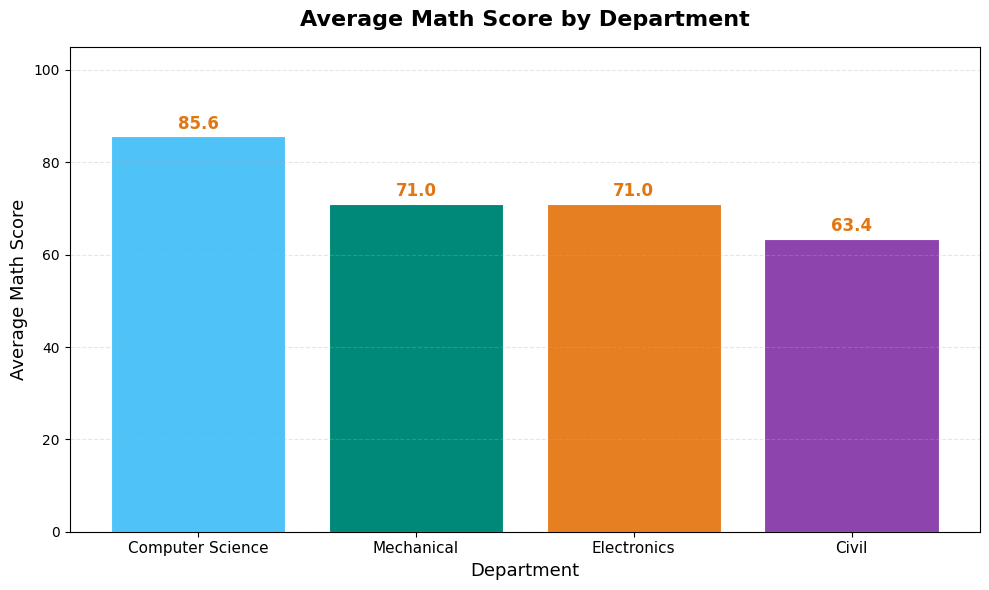

In [ ]:
chart1_sql="""
  SELECT department,ROUND(AVG(math_score),2) AS  avg_math
  FROM students
  GROUP BY department
  ORDER BY avg_math DESC
  """
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=['#4FC3F7','#008978','#E67E22','#8E44AD']
bars=ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f}',
      ha='center',va='bottom',
      fontsize=12,fontweight='bold',
      color='#E27610'
  )
ax.set_title('Average Math Score by Department',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Department',fontsize=13)
ax.set_ylabel('Average Math Score',fontsize=13)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()

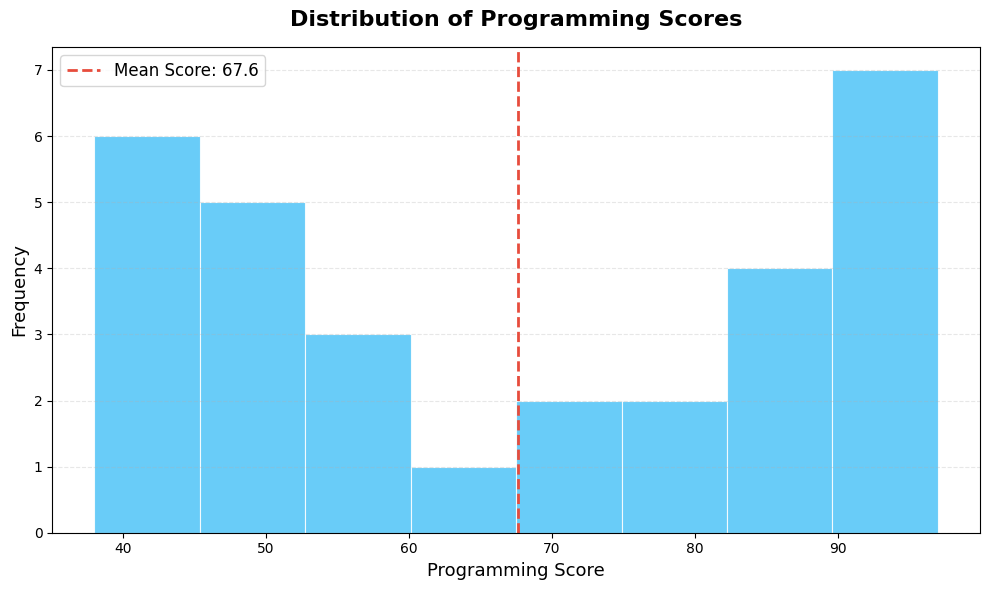

In [ ]:
#chart2

prog_scores = df['programming_score'].tolist()

fig, ax = plt.subplots(figsize=(10,6))
n,bins, patches = ax.hist(
    prog_scores,
    bins=8,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
mean_score = sum(prog_scores)/len(prog_scores)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean Score: {mean_score:.1f}'
)

ax.set_title('Distribution of Programming Scores', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Programming Score', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
#

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

df = pd.DataFrame({
    'Category': np.random.choice(['A', 'B', 'C'], size=100),
    'Value': np.random.randint(10,100,100),
    'Score':np.random.randint(1,10,100)
})
df.head()

,Category,Value,Score
0,C,55,2
1,A,40,2
2,A,99,1
3,C,85,4
4,C,54,4


In [ ]:
import plotly.express as px

# Calculate category counts from the 'df' DataFrame
category_counts = df['Category'].value_counts().reset_index()
category_counts.columns=['Category','Count']

fig=px.bar(
    category_counts,
    x='Category',
    y='Count',
    color='Category',
    title='Interactive Category Distribution',
    text='Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title='Category',yaxis_title='Count')
fig.show()


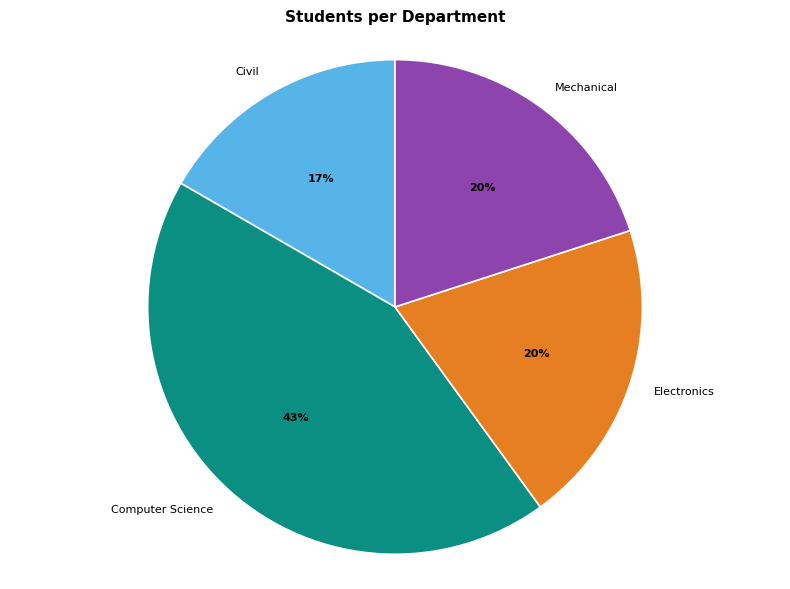

In [23]:
number_of_students_query = """
    SELECT
        department,
        COUNT(*) AS num_students
    FROM students
    GROUP BY department
"""

# Read data
number_of_students_df = pd.read_sql_query(
    number_of_students_query,
    conn
)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Colors like image
colors = ['#56B4E9', '#0B8F83', '#E67E22', '#8E44AD']

# Create pie chart
wedges, texts, autotexts = ax.pie(
    number_of_students_df['num_students'],
    labels=number_of_students_df['department'],
    autopct='%1.0f%%',
    startangle=90,
    colors=colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1.2
    },
    textprops={
        'fontsize': 8
    }
)

# Percentage text style
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')

# Title
ax.set_title(
    'Students per Department',
    fontsize=11,
    fontweight='bold',
    pad=10
)

# Make circle perfect
ax.axis('equal')

# Clean layout
plt.tight_layout()

# Show chart
plt.show()

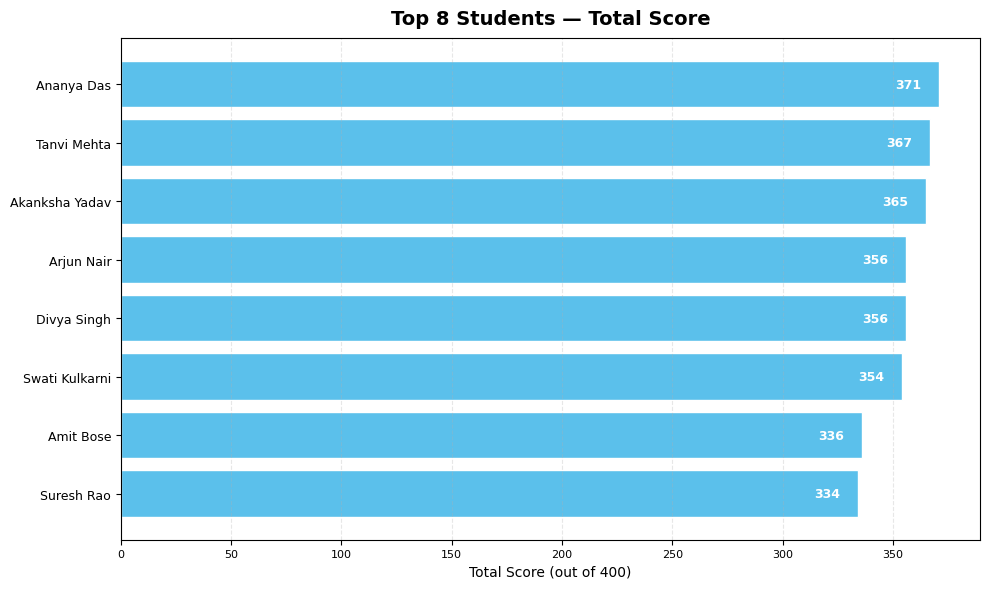

In [24]:
total_score_query = """
    SELECT
        name,
        math_score + science_score + english_score + programming_score AS total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 8
"""

# Read data
total_score_df = pd.read_sql_query(total_score_query, conn)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart
bars = ax.barh(
    total_score_df['name'],
    total_score_df['total_score'],
    color='#5BC0EB',        # Light blue like image
    edgecolor='white',
    linewidth=1,
    height=0.8
)

# Add score labels inside bars
for bar in bars:
    width = bar.get_width()

    ax.text(
        width - 8,                          # Position inside bar
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        ha='right',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='white'
    )

# Title and labels
ax.set_title(
    'Top 8 Students — Total Score',
    fontsize=14,
    fontweight='bold',
    pad=10
)

ax.set_xlabel('Total Score (out of 400)', fontsize=10)
ax.set_ylabel('')

# Grid style
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Highest score at top
ax.invert_yaxis()

# Tick sizes
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=9)

# Clean layout
plt.tight_layout()

# Show graph
plt.show()

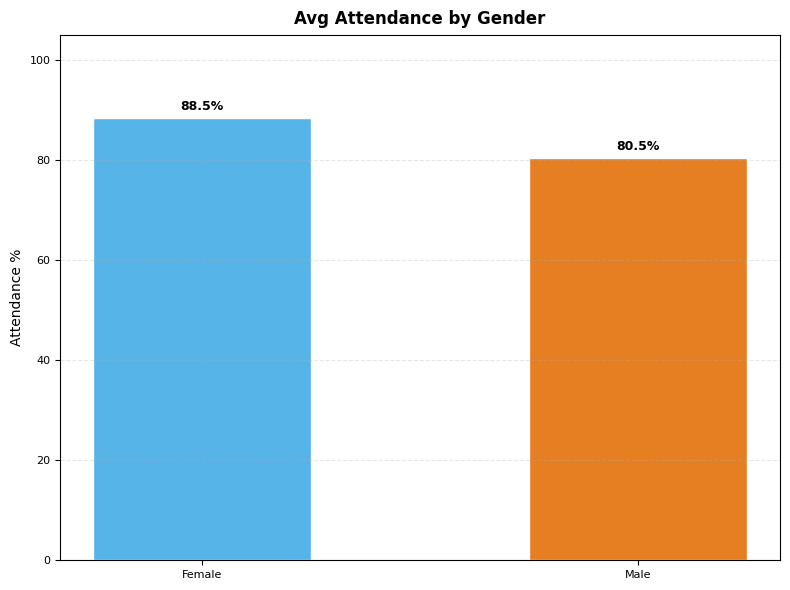

In [25]:
avg_attendance_percentage_query = """
    SELECT
        gender,
        ROUND(AVG(attendance_percentage), 1) AS avg_attendance
    FROM students
    GROUP BY gender
"""

# Read data
avg_attendance_percentage_df = pd.read_sql_query(
    avg_attendance_percentage_query,
    conn
)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Bar colors like image
bar_colors = ['#56B4E9', '#E67E22']

# Create bar chart
bars = ax.bar(
    avg_attendance_percentage_df['gender'],
    avg_attendance_percentage_df['avg_attendance'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1,
    width=0.5
)

# Add percentage labels on top
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

# Title
ax.set_title(
    'Avg Attendance by Gender',
    fontsize=12,
    fontweight='bold',
    pad=8
)

# Y-axis label
ax.set_ylabel('Attendance %')

# Set limits
ax.set_ylim(0, 105)

# Grid style
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Tick sizes
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# Clean layout
plt.tight_layout()

# Show graph
plt.show()

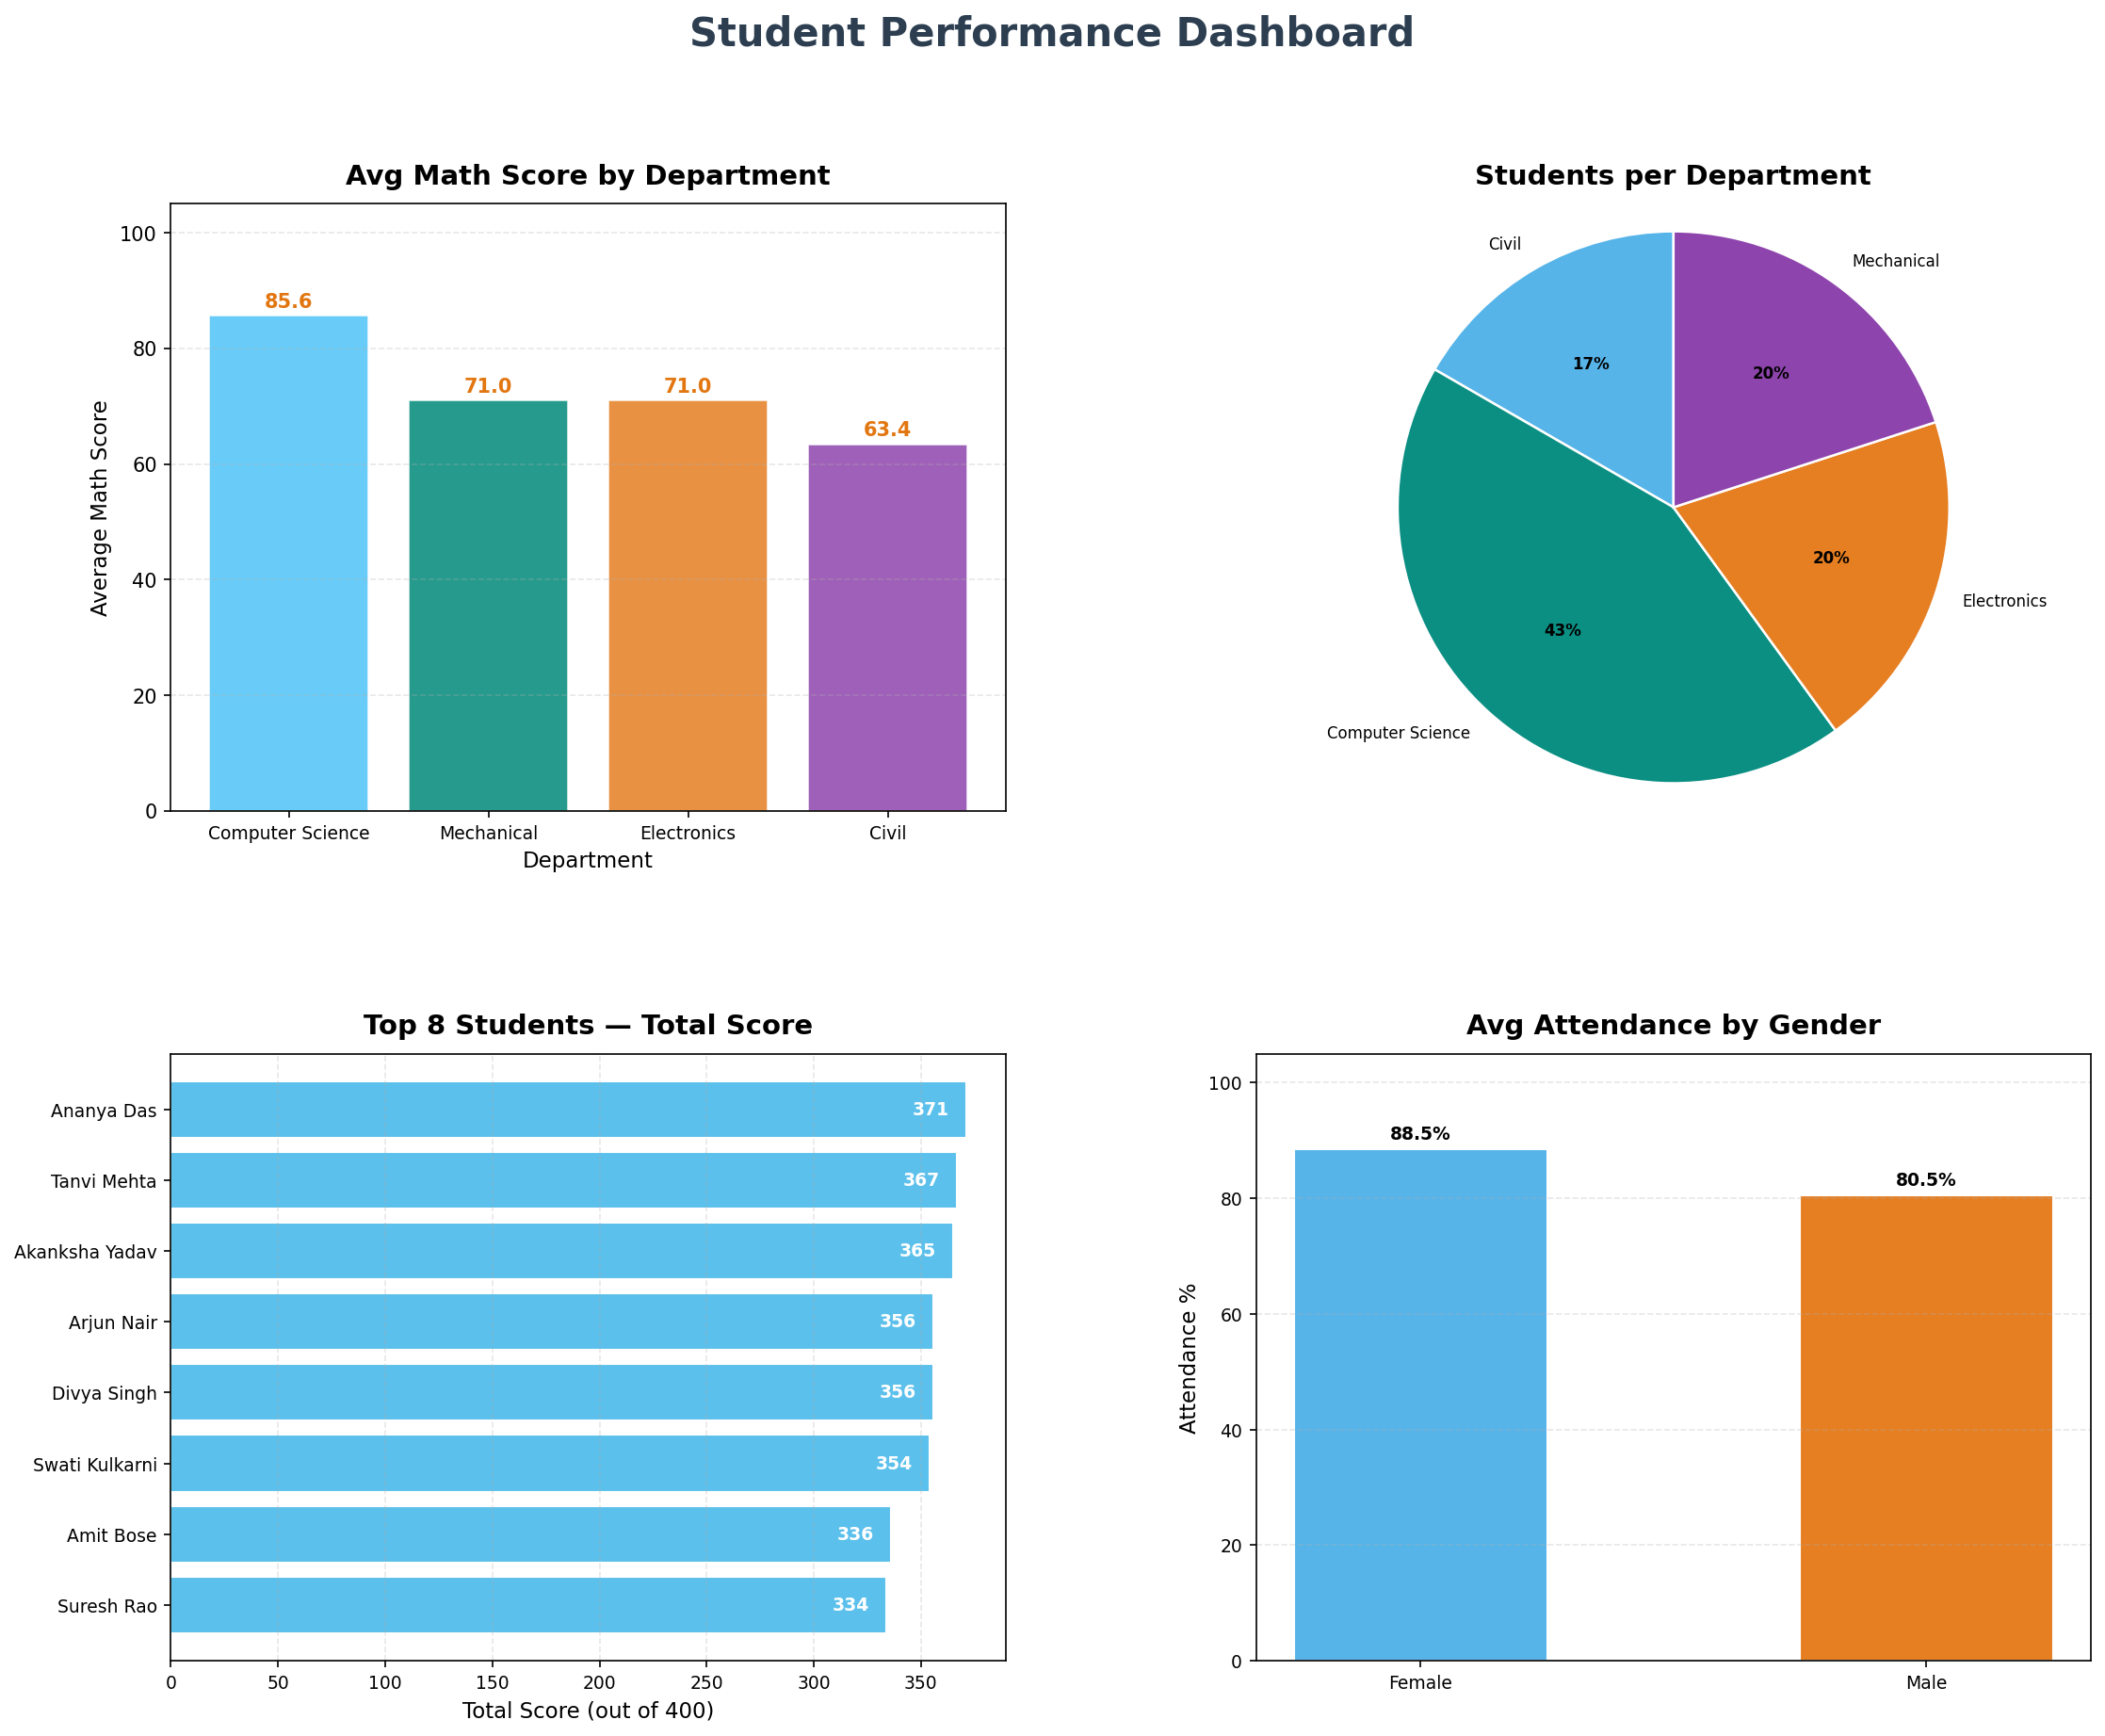

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12), dpi=150) # Create 2x2 subplots for the dashboard

# --- Panel 1: Average Math Score by Department (from t_Kq8UYCP2QB) ---
avg_math_score_query = """
    SELECT
        department,
        ROUND(AVG(math_score), 1) AS avg_math_score
    FROM students
    GROUP BY department
    ORDER BY avg_math_score DESC
"""
avg_math_score_df = pd.read_sql_query(avg_math_score_query, conn)
ax = axes[0, 0] # Assign to top-left subplot
bar_colors = ['#4FC3F7', '#008978', '#E67E22', '#8E44AD']
bars = ax.bar(
    avg_math_score_df['department'],
    avg_math_score_df['avg_math_score'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#E27610'
    )
ax.set_title('Avg Math Score by Department', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Department', fontsize=11)
ax.set_ylabel('Average Math Score', fontsize=11)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# --- Panel 2: Students per Department Pie Chart (from cCLom8iOQCh_) ---
number_of_students_query = """
    SELECT
        department,
        COUNT(*) AS num_students
    FROM students
    GROUP BY department
"""
number_of_students_df = pd.read_sql_query(number_of_students_query, conn)
ax = axes[0, 1] # Assign to top-right subplot
colors = ['#56B4E9', '#0B8F83', '#E67E22', '#8E44AD']
wedges, texts, autotexts = ax.pie(
    number_of_students_df['num_students'],
    labels=number_of_students_df['department'],
    autopct='%1.0f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'fontsize': 8}
)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')
ax.set_title('Students per Department', fontsize=14, fontweight='bold', pad=10)
ax.axis('equal')

# --- Panel 3: Top 8 Students by Total Score (from W259Z9ygQGDc) ---
total_score_query = """
    SELECT
        name,
        math_score + science_score + english_score + programming_score AS total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 8
"""
total_score_df = pd.read_sql_query(total_score_query, conn)
ax = axes[1, 0] # Assign to bottom-left subplot
bars = ax.barh(
    total_score_df['name'],
    total_score_df['total_score'],
    color='#5BC0EB',
    edgecolor='white',
    linewidth=1,
    height=0.8
)
for bar in bars:
    width = bar.get_width()
    ax.text(
        width - 8,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        ha='right', va='center',
        fontsize=9, fontweight='bold',
        color='white'
    )
ax.set_title('Top 8 Students — Total Score', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Total Score (out of 400)', fontsize=11)
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.invert_yaxis()
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

# --- Panel 4: Average Attendance Percentage by Gender (from J4uGKam8QJkI) ---
avg_attendance_percentage_query = """
    SELECT
        gender,
        ROUND(AVG(attendance_percentage), 1) AS avg_attendance
    FROM students
    GROUP BY gender
"""
avg_attendance_percentage_df = pd.read_sql_query(avg_attendance_percentage_query, conn)
ax = axes[1, 1] # Assign to bottom-right subplot
bar_colors = ['#56B4E9', '#E67E22']
bars = ax.bar(
    avg_attendance_percentage_df['gender'],
    avg_attendance_percentage_df['avg_attendance'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1,
    width=0.5
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold',
        color='black'
    )
ax.set_title('Avg Attendance by Gender', fontsize=14, fontweight='bold', pad=10)
ax.set_ylabel('Attendance %', fontsize=11)
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

# --- Dashboard Customization ---
fig.suptitle(
    'Student Performance Dashboard',
    fontsize=20,
    fontweight='bold',
    color='#2C3E50',
    y=1.02 # Adjust title position to be above subplots
)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
fig.subplots_adjust(wspace=0.3, hspace=0.4) # Fine-tune spacing between subplots

# Save the dashboard
plt.savefig('student_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()